In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Regresión Logística — BNPL Credit Risk Dataset

**Objetivo:** Predecir si un cliente caerá en *default* (`default_flag`) sobre un crédito Buy Now Pay Later, en función de su perfil financiero y de comportamiento de pago.

**Dataset:** `Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv` — registros de clientes BNPL con variables demográficas, financieras y de historial de pagos.

In [3]:
df = pd.read_csv("Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
df.head(10)

Shape: (10345, 17)

Columnas: ['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score', 'purchase_amount', 'product_category', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 'location', 'transaction_date', 'debt_to_income_ratio', 'risk_score', 'customer_segment']


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk
5,6,52,Self-Employed,79950.32,729,5000.00,Fashion,9,1,0,0,6.32,Canada,2024-08-29,0.062539,50.4,Low Risk
6,7,44,Salaried,43192.27,511,5000.00,Sports,3,2,0,0,5.58,USA,2024-08-21,0.115761,139.6,High Risk
7,8,54,Unemployed,9434.80,369,1686.24,Fashion,3,0,0,1,3.66,Germany,2024-11-17,0.178726,192.4,High Risk
8,9,45,Student,14821.44,306,3628.68,Electronics,9,20,2,1,2.48,USA,2024-11-14,0.244826,297.6,High Risk
9,10,54,Unemployed,6737.92,318,100.00,Home,6,4,0,0,9.66,UK,2023-06-09,0.014841,220.8,High Risk


## 2. Análisis Exploratorio (EDA)

### 2.1 Información general y valores nulos

In [4]:
# Agrupamos columnas por tipo para reutilizar en todo el EDA
num_cols = ["age", "monthly_income", "credit_score", "purchase_amount",
            "bnpl_installments", "repayment_delay_days", "missed_payments",
            "app_usage_frequency", "debt_to_income_ratio", "risk_score"]
cat_cols = ["employment_type", "product_category", "location", "customer_segment"]
target   = "default_flag"

df.info()
print("\n--- Valores nulos ---")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  str    
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  str    
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  str    
 13  transaction_date      10345 non-null  str    
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score            10345 no

### 2.2 Balance de la variable objetivo

En clasificación, el balance de clases determina qué métricas son confiables. Si `default_flag` está muy desbalanceado, el *accuracy* puede ser engañoso y conviene mirar *precision*, *recall* y la matriz de confusión.

Conteo por clase:
default_flag
0    6305
1    4040
Name: count, dtype: int64

Proporción por clase:
default_flag
0    60.95 %
1    39.05 %
Name: proportion, dtype: str


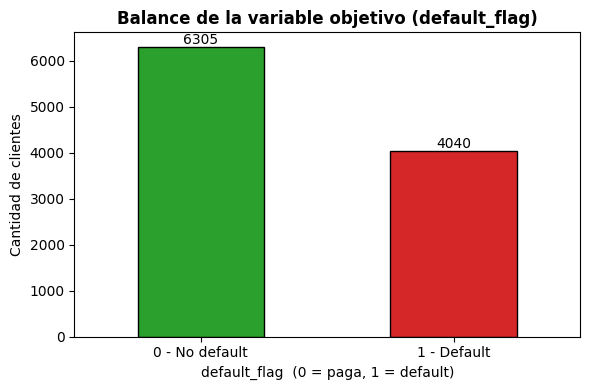

In [5]:
counts = df[target].value_counts().sort_index()
props  = df[target].value_counts(normalize=True).sort_index()

print("Conteo por clase:")
print(counts)
print("\nProporción por clase:")
print((props * 100).round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", color=["#2ca02c", "#d62728"], edgecolor="black", ax=ax)
ax.set_title("Balance de la variable objetivo (default_flag)", fontweight="bold")
ax.set_xlabel("default_flag  (0 = paga, 1 = default)")
ax.set_ylabel("Cantidad de clientes")
ax.set_xticklabels(["0 - No default", "1 - Default"], rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

### 2.3 Estadísticas descriptivas

In [6]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,10345.0,38.559884,12.131789,18.000000,28.000000,39.000000,49.0000,59.00000
monthly_income,10345.0,35053.381898,27084.517277,5000.000000,12207.020000,23800.520000,55276.9300,145767.12000
credit_score,10345.0,448.176124,136.518332,300.000000,332.000000,403.000000,547.0000,850.00000
purchase_amount,10345.0,3979.402721,1500.828483,100.000000,2990.720000,5000.000000,5000.0000,5000.00000
bnpl_installments,10345.0,7.477525,3.362867,3.000000,3.000000,9.000000,9.0000,12.00000
repayment_delay_days,10345.0,8.742774,6.781849,0.000000,2.000000,9.000000,14.0000,33.00000
missed_payments,10345.0,1.015950,0.996726,0.000000,0.000000,1.000000,2.0000,7.00000
app_usage_frequency,10345.0,5.524101,2.590364,1.000000,3.300000,5.550000,7.7500,10.00000
debt_to_income_ratio,10345.0,0.181071,0.124887,0.000811,0.080187,0.138263,0.2683,0.72346
risk_score,10345.0,198.534094,67.541384,0.000000,153.600000,202.800000,250.8000,398.00000


### 2.4 Distribución de variables categóricas

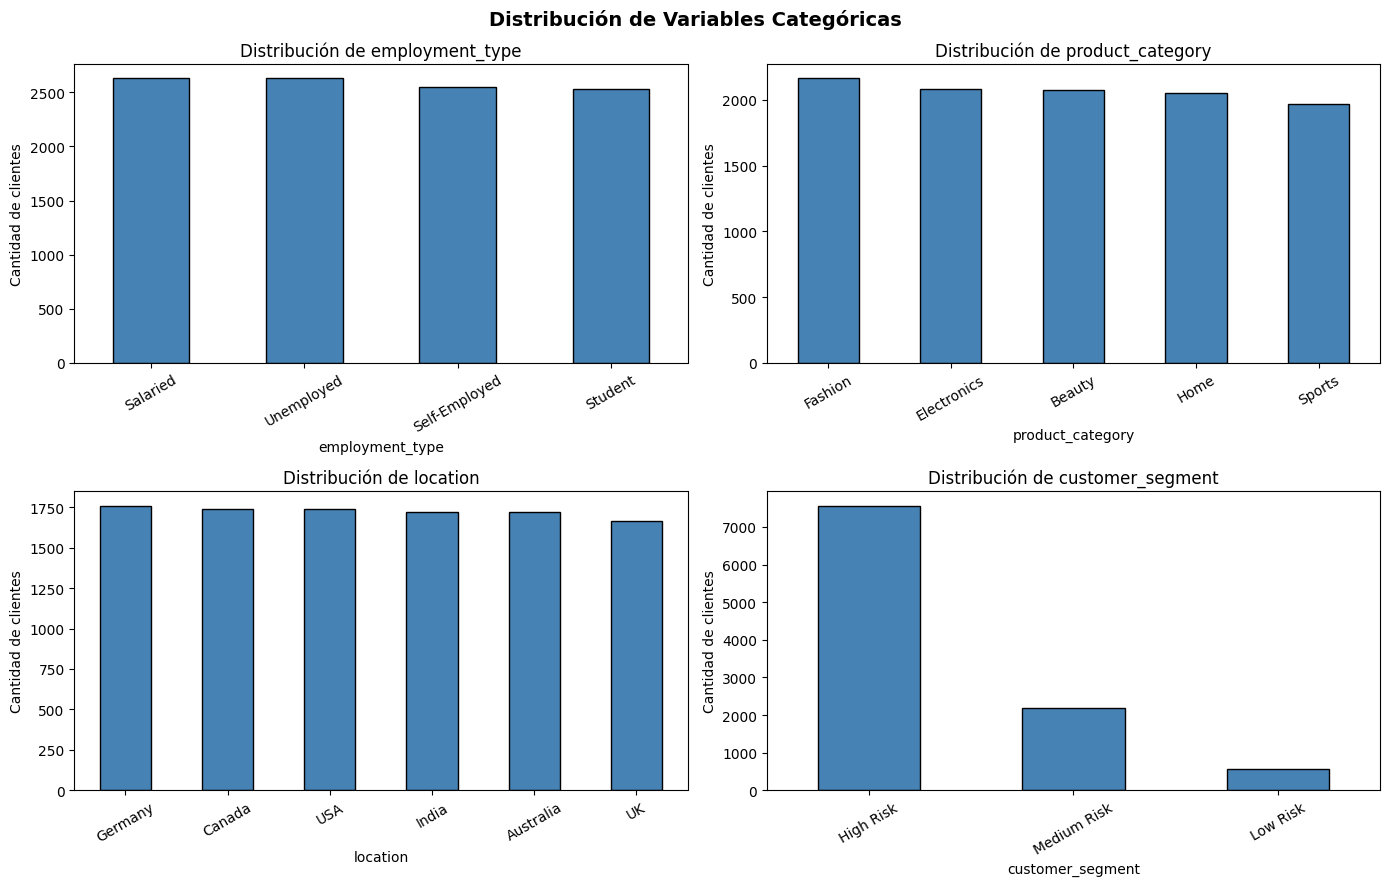

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Cantidad de clientes")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Distribución de Variables Categóricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.5 Distribución de variables numéricas (histogramas)

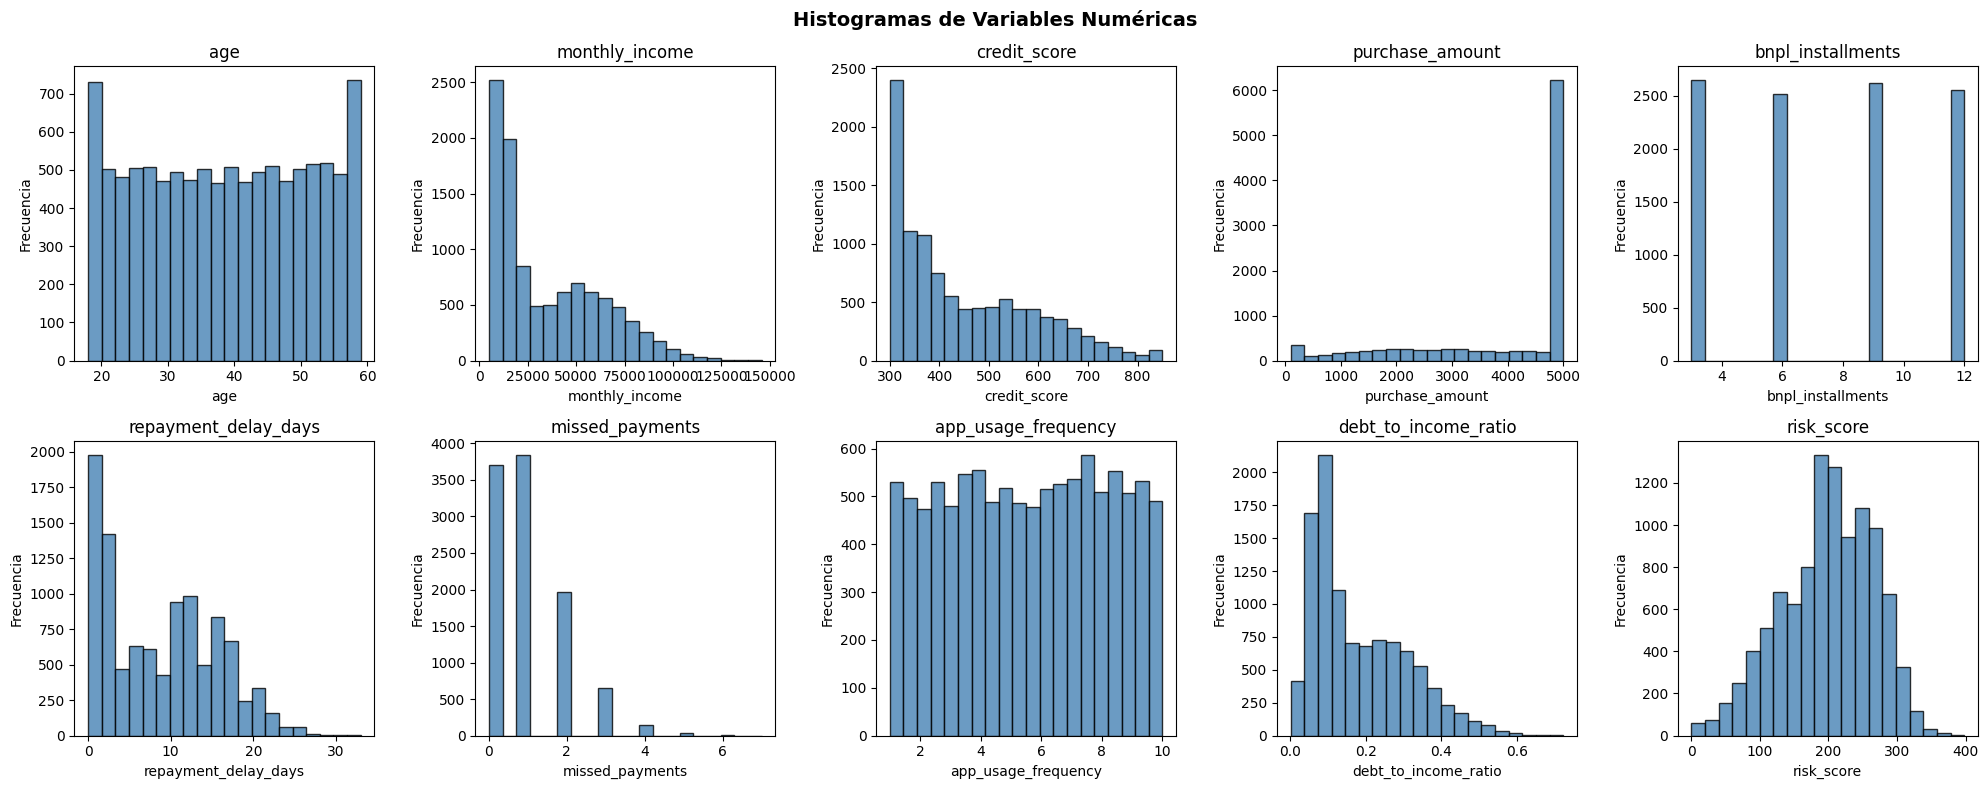

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color="steelblue", edgecolor="black", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Histogramas de Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.6 Variables numéricas vs `default_flag` (boxplots)

Comparamos la distribución de cada variable numérica entre clientes que cayeron en default (1) y los que no (0). Si las cajas se separan claramente, esa variable tiene poder predictivo.

C:\Users\jenar\AppData\Local\Temp\ipykernel_29744\2121222476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=["#2ca02c", "#d62728"], ax=axes[i])
C:\Users\jenar\AppData\Local\Temp\ipykernel_29744\2121222476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=["#2ca02c", "#d62728"], ax=axes[i])
C:\Users\jenar\AppData\Local\Temp\ipykernel_29744\2121222476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=["#2ca02c", "#d62728"], ax=axes[i]

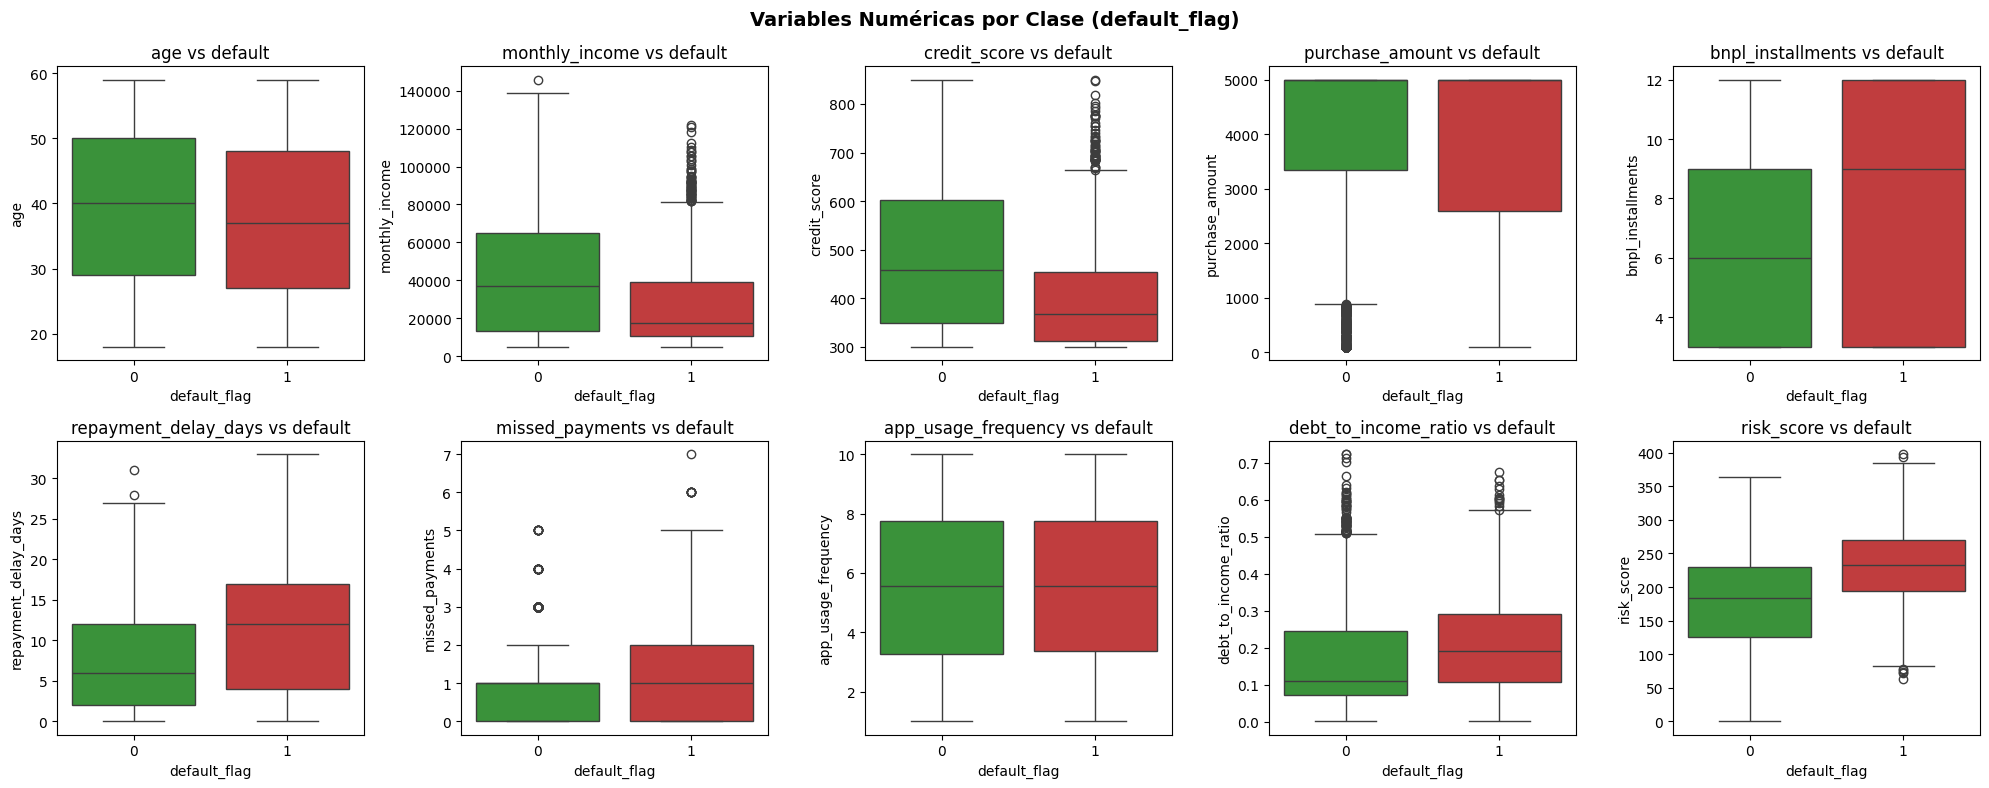

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=target, y=col, palette=["#2ca02c", "#d62728"], ax=axes[i])
    axes[i].set_title(f"{col} vs default")
    axes[i].set_xlabel("default_flag")

plt.suptitle("Variables Numéricas por Clase (default_flag)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.7 Heatmap de correlaciones

Incluimos `default_flag` en la matriz para ver qué variables numéricas se relacionan más con el evento de default.

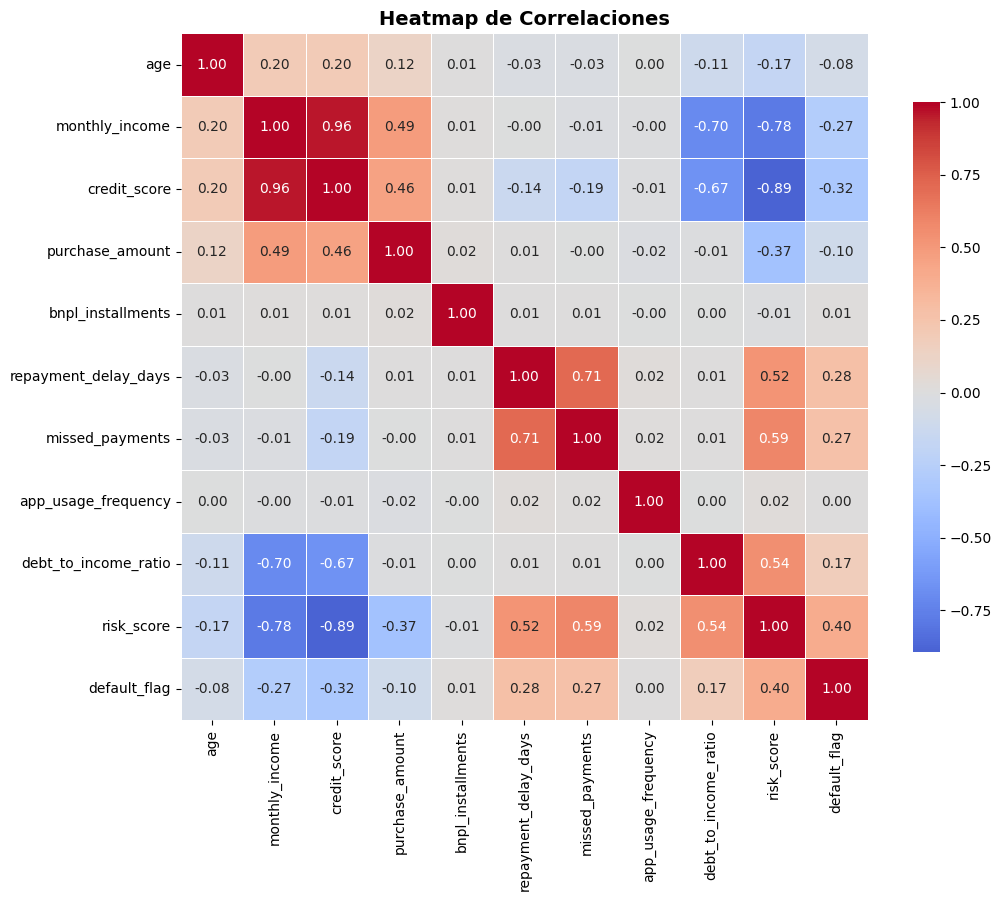


Correlación de cada variable con default_flag:
risk_score              0.399379
repayment_delay_days    0.283209
missed_payments         0.272267
debt_to_income_ratio    0.172947
bnpl_installments       0.012244
app_usage_frequency     0.003864
age                    -0.075702
purchase_amount        -0.097912
monthly_income         -0.274163
credit_score           -0.324238
Name: default_flag, dtype: float64


In [10]:
plt.figure(figsize=(11, 9))
corr = df[num_cols + [target]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Heatmap de Correlaciones", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nCorrelación de cada variable con default_flag:")
print(corr[target].drop(target).sort_values(ascending=False))

### 2.8 Scatter Matrix — todas las variables predictoras (num + OHE)

Primero aplicamos *one-hot encoding* a las categóricas (`drop_first=True` para evitar la trampa del dummy) y construimos la matriz de predictores completa. El scatter matrix permite ver visualmente relaciones lineales y no lineales entre pares de variables.

Variables predictoras tras OHE: 24
['age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed', 'product_category_Electronics', 'product_category_Fashion', 'product_category_Home', 'product_category_Sports', 'location_Canada', 'location_Germany', 'location_India', 'location_UK', 'location_USA', 'customer_segment_Low Risk', 'customer_segment_Medium Risk']


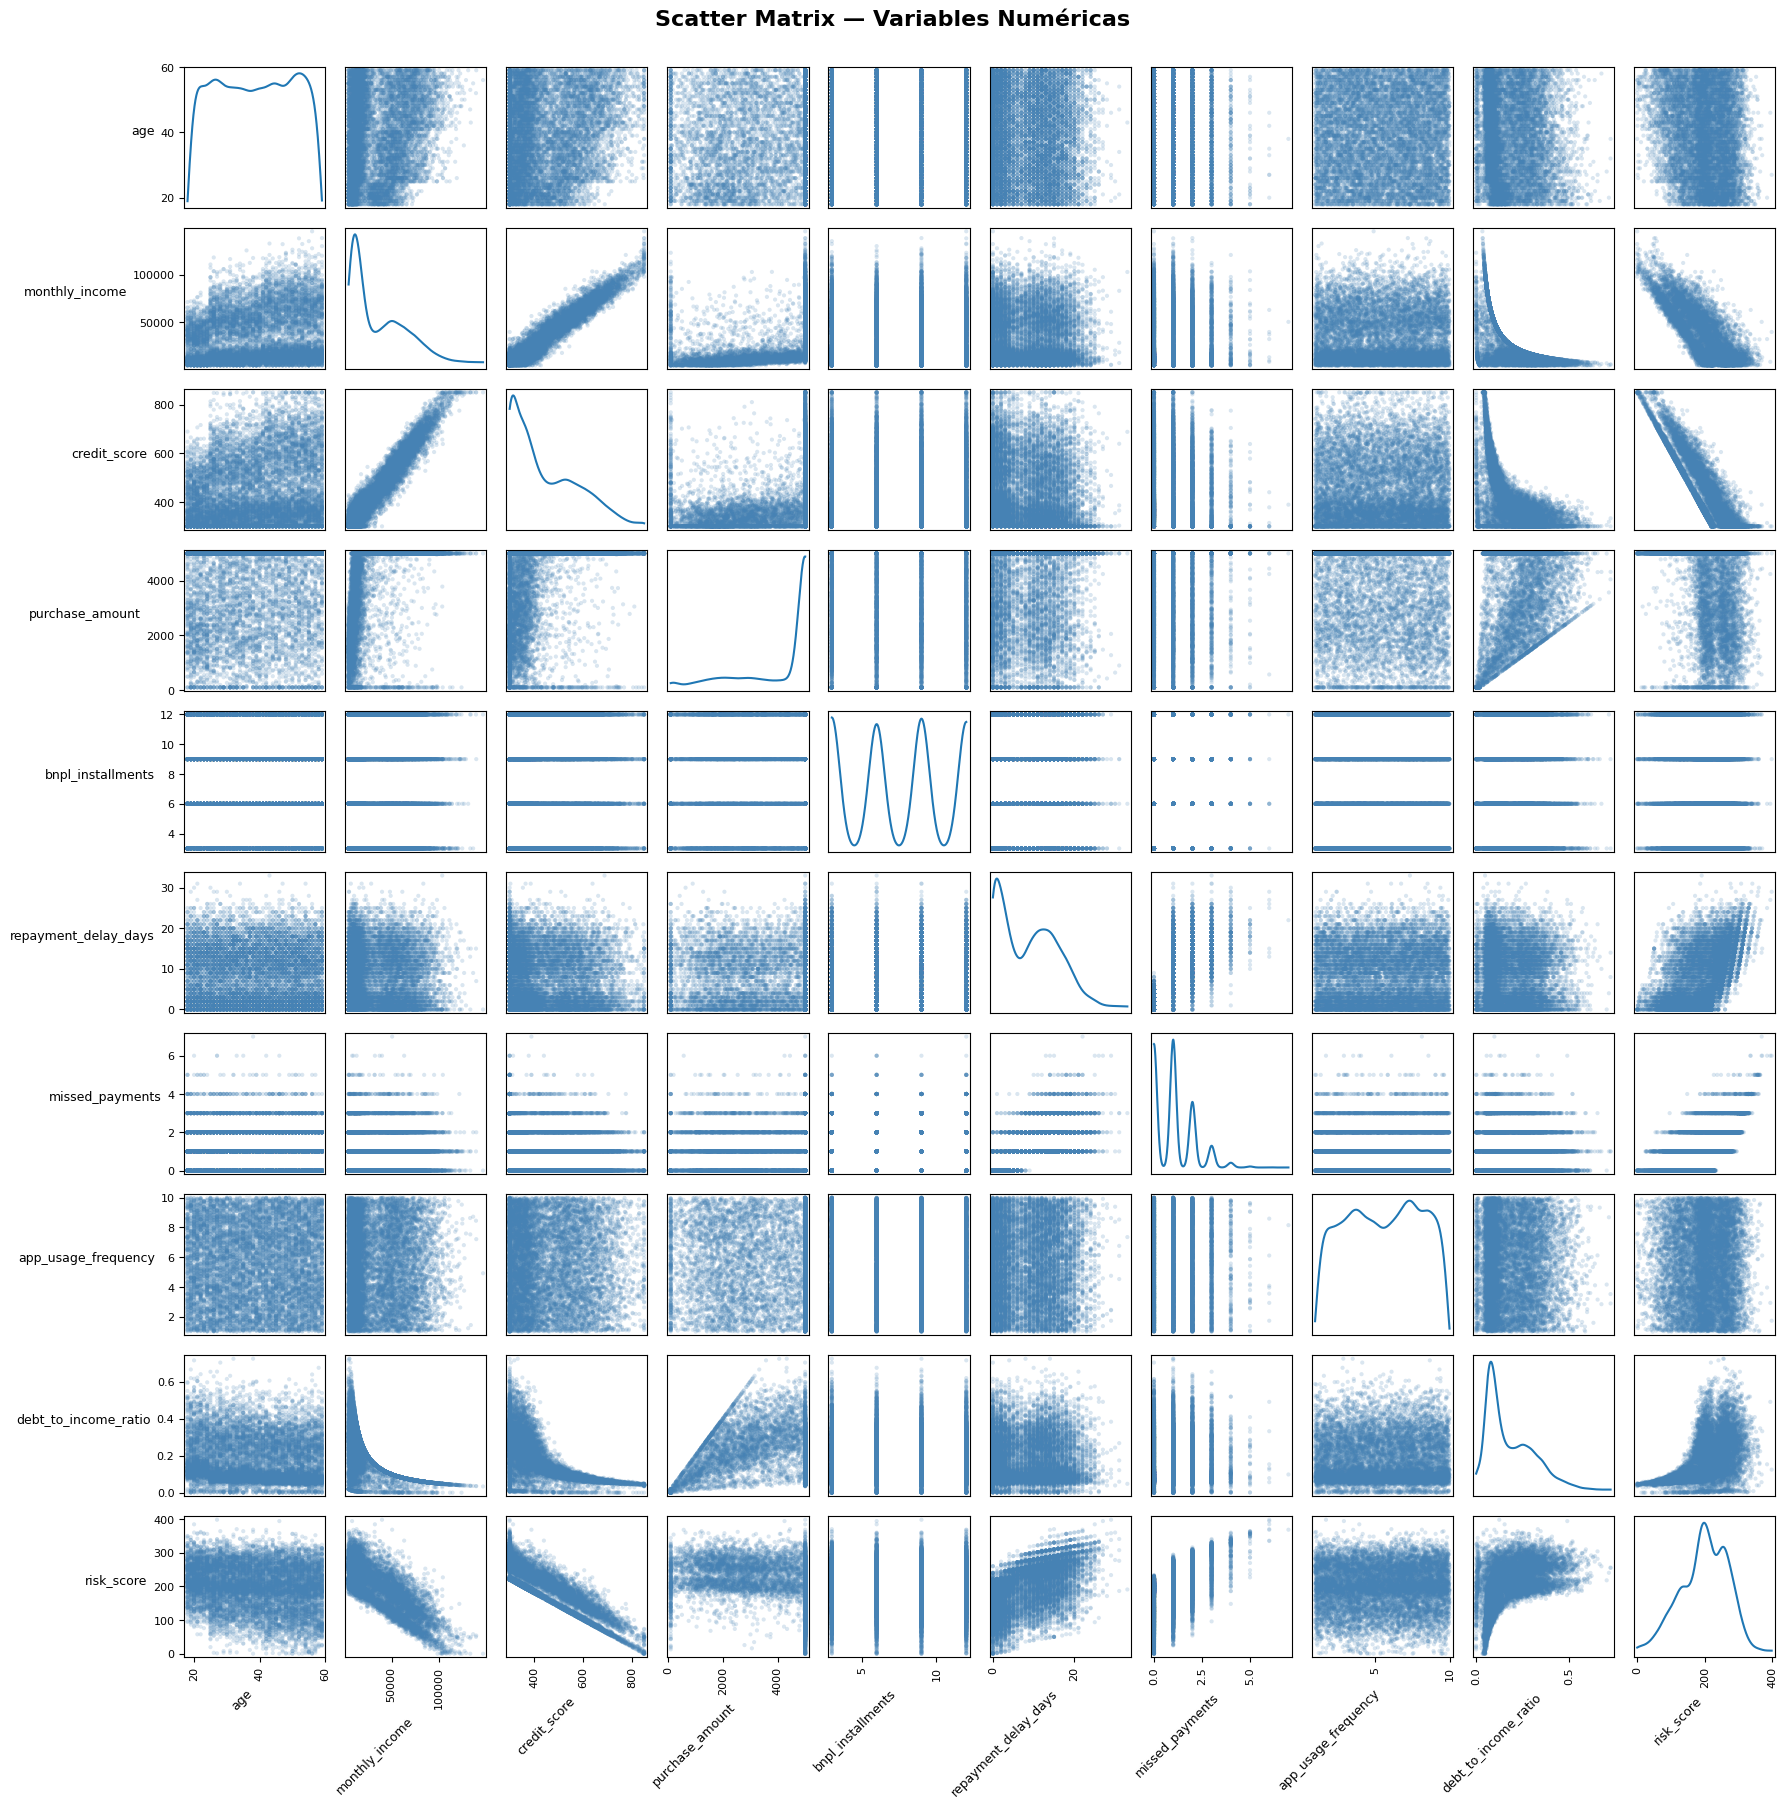

In [11]:
from pandas.plotting import scatter_matrix

# One-hot encoding — se usa para VIF; el scatter matrix solo muestra numéricas
X_raw = df.drop(columns=["user_id", "transaction_date", target])
X_enc = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

print(f"Variables predictoras tras OHE: {X_enc.shape[1]}")
print(list(X_enc.columns))

# Scatter matrix — solo variables numéricas (las dummies binarias no aportan visualmente)
axes = scatter_matrix(
    df[num_cols],
    alpha=0.2,
    figsize=(18, 18),
    diagonal="kde",
    color="steelblue"
)

for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.label.set_rotation(45)
        ax.xaxis.label.set_ha("right")
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha("right")
        ax.yaxis.label.set_fontsize(9)
        ax.xaxis.label.set_fontsize(9)

plt.suptitle("Scatter Matrix — Variables Numéricas", fontsize=16, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()

### 2.9 VIF — Variance Inflation Factor

El VIF mide cuánto se infla la varianza de un coeficiente por la correlación con las demás variables.  
Regla de dedo habitual: **VIF > 5** → multicolinealidad moderada; **VIF > 10** → multicolinealidad alta.

                     Variable        VIF
                 credit_score 125.071680
                   risk_score  69.921456
               monthly_income  28.900452
              missed_payments   8.776957
         repayment_delay_days   6.565149
   employment_type_Unemployed   4.379267
         debt_to_income_ratio   3.936236
      employment_type_Student   3.290622
    customer_segment_Low Risk   3.170187
              purchase_amount   2.690345
 customer_segment_Medium Risk   2.376861
             location_Germany   1.680129
              location_Canada   1.674432
                 location_USA   1.673150
               location_India   1.669363
                  location_UK   1.653384
     product_category_Fashion   1.619752
 product_category_Electronics   1.605523
        product_category_Home   1.599675
employment_type_Self-Employed   1.582609
      product_category_Sports   1.582552
                          age   1.153475
          app_usage_frequency   1.002459
            bnpl

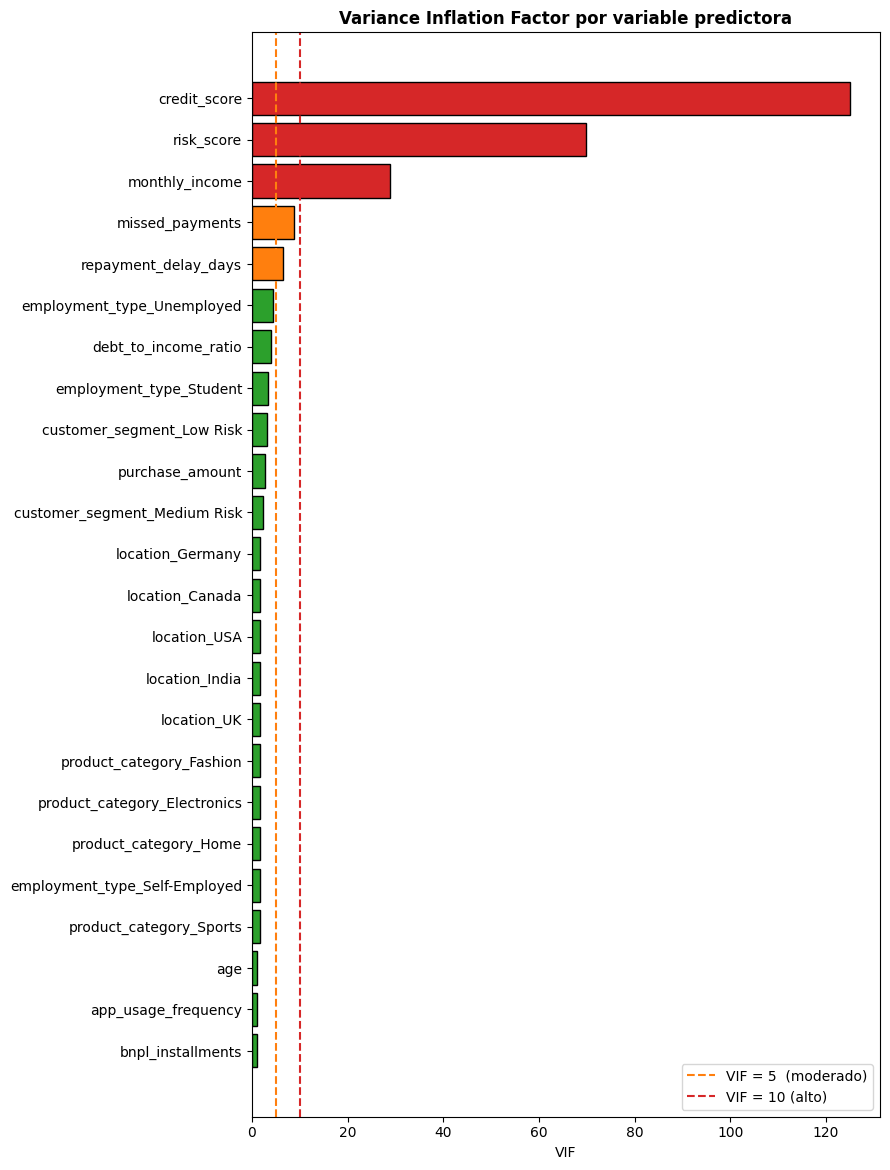

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_enc.astype(float)

vif_df = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))

# Gráfica de barras horizontal
colors = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_df["VIF"]
]

fig, ax = plt.subplots(figsize=(9, len(vif_df) * 0.45 + 1))
ax.barh(vif_df["Variable"], vif_df["VIF"], color=colors, edgecolor="black")
ax.axvline(5,  color="#ff7f0e", linestyle="--", linewidth=1.5, label="VIF = 5  (moderado)")
ax.axvline(10, color="#d62728", linestyle="--", linewidth=1.5, label="VIF = 10 (alto)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor por variable predictora", fontweight="bold")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

### 2.10 VIF — Subconjunto sin `risk_score` ni `monthly_income`

`risk_score` se elimina por probable data leakage. `monthly_income` se elimina porque `credit_score` y `debt_to_income_ratio` ya capturan esa información de forma más condensada.

                     Variable       VIF
                 credit_score 37.560033
              purchase_amount 18.858358
                          age 12.511004
         debt_to_income_ratio  9.281183
            bnpl_installments  5.754122
         repayment_delay_days  5.425927
          app_usage_frequency  5.390838
   employment_type_Unemployed  4.610871
              missed_payments  4.257312
      employment_type_Student  3.335673
 customer_segment_Medium Risk  2.236611
employment_type_Self-Employed  2.082860
     product_category_Fashion  2.005635
             location_Germany  1.981335
 product_category_Electronics  1.980584
              location_Canada  1.973986
                 location_USA  1.970871
               location_India  1.959129
        product_category_Home  1.952942
    customer_segment_Low Risk  1.938504
                  location_UK  1.922919
      product_category_Sports  1.917371


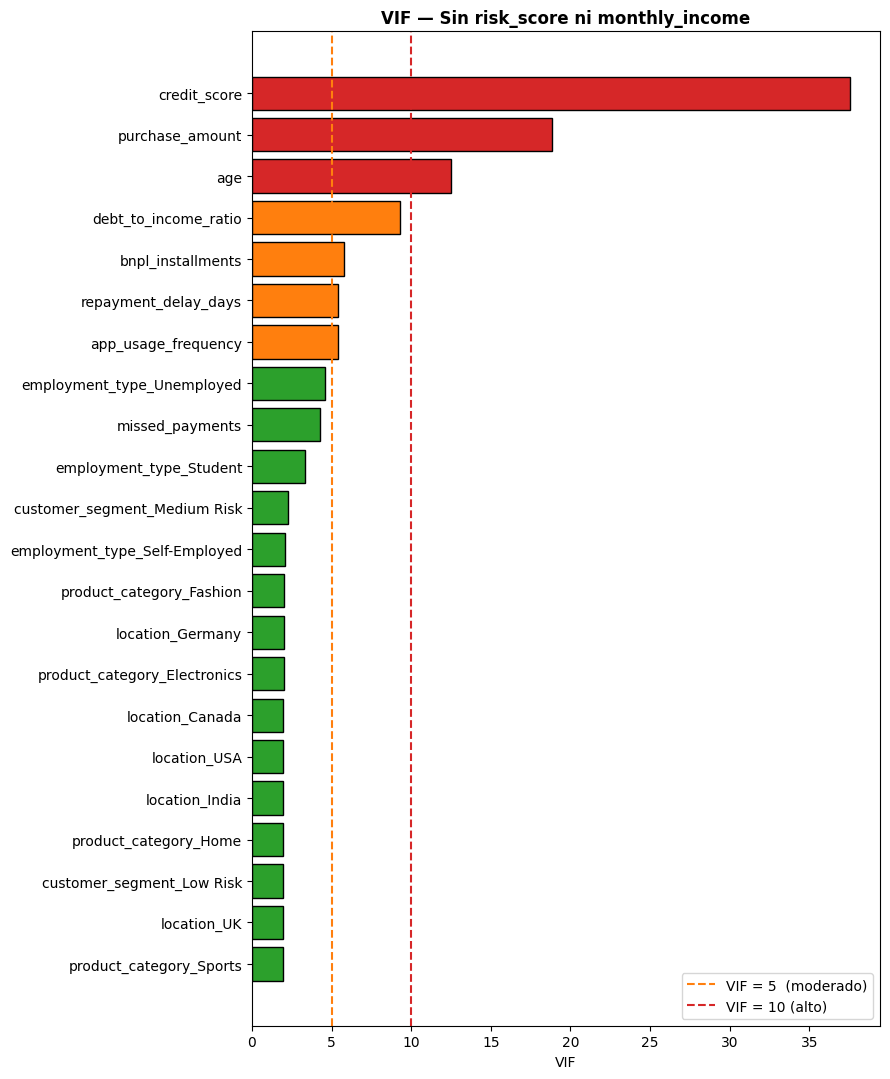

In [13]:
drop_cols = ["user_id", "transaction_date", target, "risk_score", "monthly_income"]
X_raw2 = df.drop(columns=drop_cols)
X_enc2 = pd.get_dummies(X_raw2, columns=cat_cols, drop_first=True)

X_vif2 = X_enc2.astype(float)

vif_df2 = pd.DataFrame({
    "Variable": X_vif2.columns,
    "VIF": [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_df2.to_string(index=False))

colors2 = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_df2["VIF"]
]

fig, ax = plt.subplots(figsize=(9, len(vif_df2) * 0.45 + 1))
ax.barh(vif_df2["Variable"], vif_df2["VIF"], color=colors2, edgecolor="black")
ax.axvline(5,  color="#ff7f0e", linestyle="--", linewidth=1.5, label="VIF = 5  (moderado)")
ax.axvline(10, color="#d62728", linestyle="--", linewidth=1.5, label="VIF = 10 (alto)")
ax.set_xlabel("VIF")
ax.set_title("VIF — Sin risk_score ni monthly_income", fontweight="bold")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

### 2.11 VIF — Variables crudas: sin `credit_score` ni `risk_score`

En lugar de usar el score compuesto, conservamos las variables que lo determinan: `monthly_income`, `missed_payments`, `repayment_delay_days`, `debt_to_income_ratio`. Esto evita incluir una variable derivada que oculta sus propios componentes.

                     Variable      VIF
         debt_to_income_ratio 5.535634
         repayment_delay_days 5.317136
            bnpl_installments 4.898423
          app_usage_frequency 4.649815
              missed_payments 4.192438
   employment_type_Unemployed 2.924329
      employment_type_Student 2.629877
employment_type_Self-Employed 1.968267
     product_category_Fashion 1.849748
 product_category_Electronics 1.841464
        product_category_Home 1.804023
                 location_USA 1.803032
             location_Germany 1.800708
              location_Canada 1.788863
               location_India 1.778258
      product_category_Sports 1.768914
                  location_UK 1.759203
 customer_segment_Medium Risk 1.599501
    customer_segment_Low Risk 1.267615


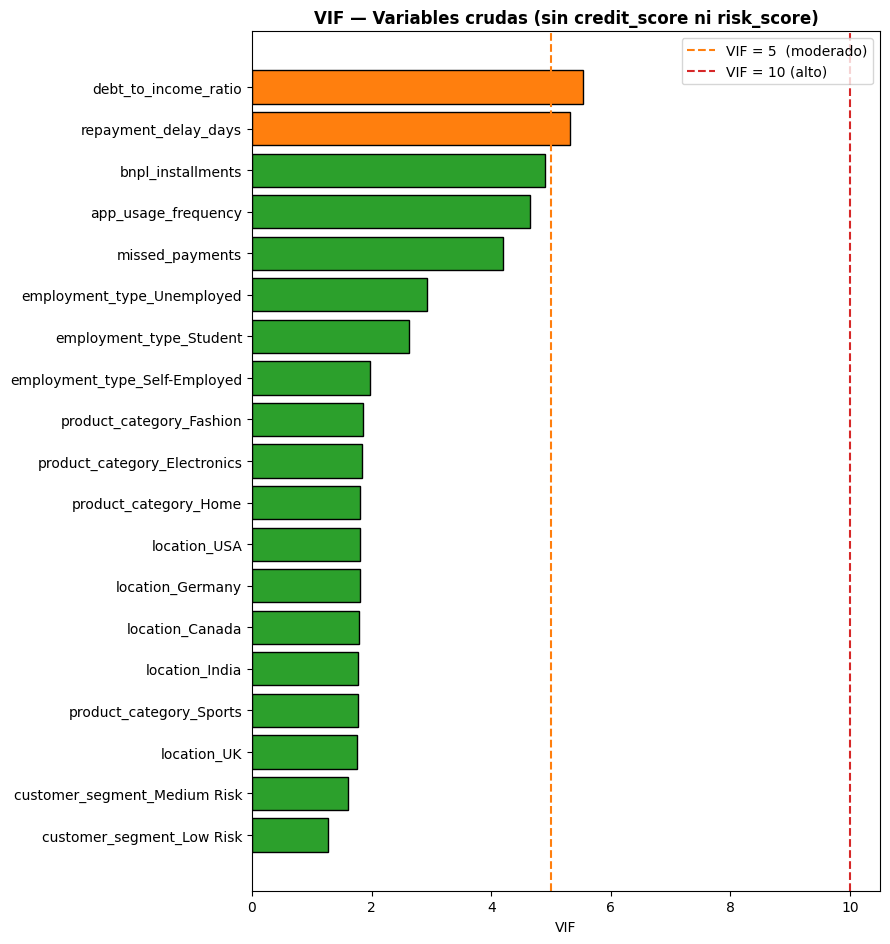

In [14]:

drop_cols3 = ["user_id", "transaction_date", target, "credit_score", "risk_score",'monthly_income','age','purchase_amount']
X_raw3 = df.drop(columns=drop_cols3)
X_enc3 = pd.get_dummies(X_raw3, columns=cat_cols, drop_first=True)

X_vif3 = X_enc3.astype(float)

vif_df3 = pd.DataFrame({
    "Variable": X_vif3.columns,
    "VIF": [variance_inflation_factor(X_vif3.values, i) for i in range(X_vif3.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_df3.to_string(index=False))

colors3 = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_df3["VIF"]
]

fig, ax = plt.subplots(figsize=(9, len(vif_df3) * 0.45 + 1))
ax.barh(vif_df3["Variable"], vif_df3["VIF"], color=colors3, edgecolor="black")
ax.axvline(5,  color="#ff7f0e", linestyle="--", linewidth=1.5, label="VIF = 5  (moderado)")
ax.axvline(10, color="#d62728", linestyle="--", linewidth=1.5, label="VIF = 10 (alto)")
ax.set_xlabel("VIF")
ax.set_title("VIF — Variables crudas (sin credit_score ni risk_score)", fontweight="bold")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## 3. Preparación de Datos

Construimos dos conjuntos de predictores para comparar estrategias:

| | **Modelo 1** | **Modelo 2** |
|---|---|---|
| Variables | Todas (menos leakage) | Reducidas (sin multicolinealidad) |
| Regularización | L2 (default sklearn) | Ninguna |
| Justificación | L2 compensa la multicolinealidad | Sin redundancia, sin penalización |

En ambos casos: OHE para categóricas, `StandardScaler` ajustado solo sobre train, `stratify=y` en el split por el desbalance 61/39.

In [15]:
from sklearn.preprocessing import StandardScaler

# --- Modelo 1: todas las variables (excepto leakage e identificadores) ---
drop_m1 = ["user_id", "transaction_date", "risk_score", target]
X1_raw = df.drop(columns=drop_m1)
X1 = pd.get_dummies(X1_raw, columns=cat_cols, drop_first=True).astype(float)

# --- Modelo 2: variables reducidas (sin multicolinealidad alta) ---
drop_m2 = ["user_id", "transaction_date", "risk_score", "credit_score",
           "monthly_income", "purchase_amount", "age", target]
X2_raw = df.drop(columns=drop_m2)
X2 = pd.get_dummies(X2_raw, columns=cat_cols, drop_first=True).astype(float)

y = df[target]

print(f"M1 — {X1.shape[1]} variables: {list(X1.columns)}")
print(f"\nM2 — {X2.shape[1]} variables: {list(X2.columns)}")

# --- Split estratificado 80/20 ---
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42, stratify=y)
X2_train, X2_test, _, _            = train_test_split(X2, y, test_size=0.2, random_state=42, stratify=y)

# --- Escalado (fit solo en train) ---
scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)
X1_test_sc  = scaler1.transform(X1_test)

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

print(f"\nTrain: {X1_train_sc.shape[0]} | Test: {X1_test_sc.shape[0]}")

M1 — 23 variables: ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed', 'product_category_Electronics', 'product_category_Fashion', 'product_category_Home', 'product_category_Sports', 'location_Canada', 'location_Germany', 'location_India', 'location_UK', 'location_USA', 'customer_segment_Low Risk', 'customer_segment_Medium Risk']

M2 — 19 variables: ['bnpl_installments', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed', 'product_category_Electronics', 'product_category_Fashion', 'product_category_Home', 'product_category_Sports', 'location_Canada', 'location_Germany', 'location_India', 'location_UK', 'location_USA', 'customer_segment_Low Risk', 'custom

## 4. Entrenamiento de Modelos

In [16]:
# Modelo 1 — todas las variables + regularización L2 (default sklearn)
m1 = LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=42)
m1.fit(X1_train_sc, y_train)

# Modelo 2 — variables reducidas + sin regularización
m2 = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
m2.fit(X2_train_sc, y_train)

print("Modelos entrenados.")

Modelos entrenados.


c:\Users\jenar\!clases\TC2034-Jenaro\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\jenar\!clases\TC2034-Jenaro\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 5. Evaluación y Comparación

In [17]:
def evaluar(nombre, modelo, X_test_sc, y_test):
    y_pred = modelo.predict(X_test_sc)
    print(f"{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print(classification_report(y_test, y_pred, target_names=["No default", "Default"]))
    return y_pred

y_pred1 = evaluar("Modelo 1 — Todas las variables + L2", m1, X1_test_sc, y_test)
y_pred2 = evaluar("Modelo 2 — Variables reducidas + sin regularización", m2, X2_test_sc, y_test)

  Modelo 1 — Todas las variables + L2
Accuracy: 0.6926

              precision    recall  f1-score   support

  No default       0.74      0.76      0.75      1261
     Default       0.61      0.59      0.60       808

    accuracy                           0.69      2069
   macro avg       0.68      0.67      0.67      2069
weighted avg       0.69      0.69      0.69      2069

  Modelo 2 — Variables reducidas + sin regularización
Accuracy: 0.6883

              precision    recall  f1-score   support

  No default       0.74      0.75      0.75      1261
     Default       0.60      0.59      0.60       808

    accuracy                           0.69      2069
   macro avg       0.67      0.67      0.67      2069
weighted avg       0.69      0.69      0.69      2069



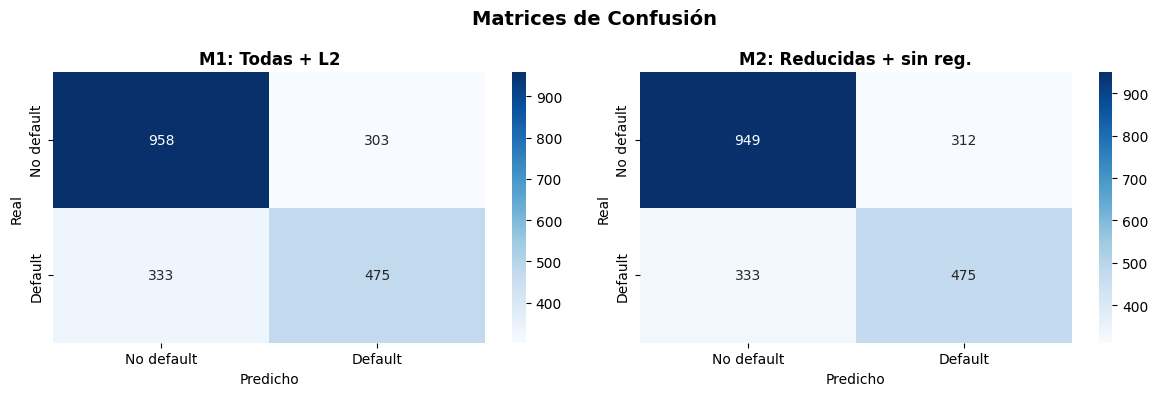

In [18]:
# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titulo in zip(axes,
                               [y_pred1, y_pred2],
                               ["M1: Todas + L2", "M2: Reducidas + sin reg."]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No default", "Default"],
                yticklabels=["No default", "Default"])
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de Confusión", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

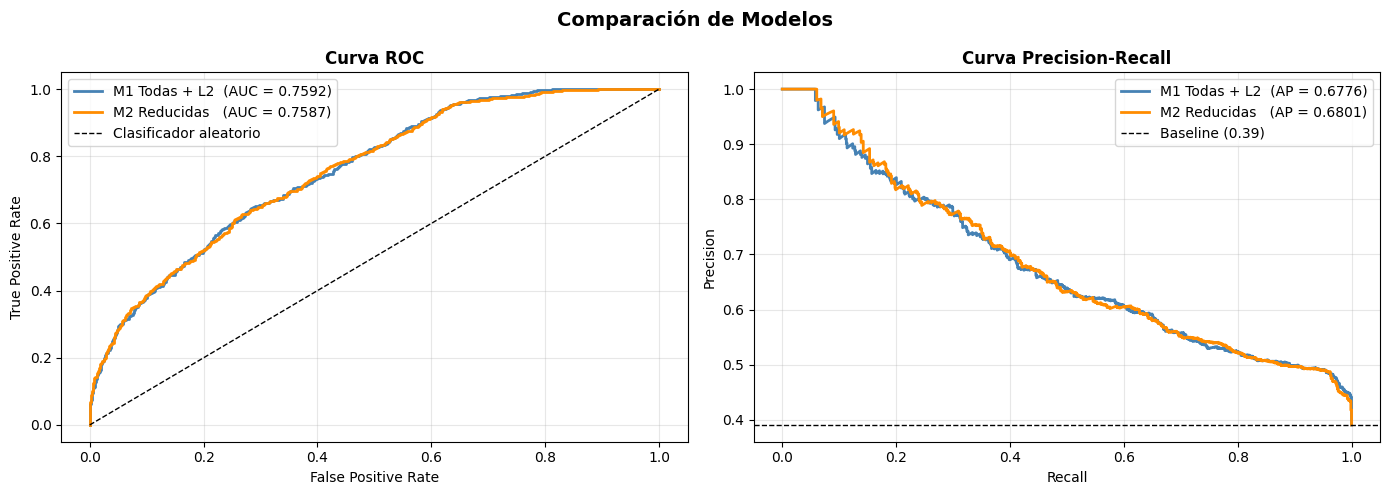

AUC  — M1: 0.7592 | M2: 0.7587 | Diferencia: 0.0005
AP   — M1: 0.6776 | M2: 0.6801 | Diferencia: 0.0025


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Probabilidades de clase positiva
y_prob1 = m1.predict_proba(X1_test_sc)[:, 1]
y_prob2 = m2.predict_proba(X2_test_sc)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, y_prob1)
fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
auc1 = roc_auc_score(y_test, y_prob1)
auc2 = roc_auc_score(y_test, y_prob2)

pr1, rc1, _ = precision_recall_curve(y_test, y_prob1)
pr2, rc2, _ = precision_recall_curve(y_test, y_prob2)
ap1 = average_precision_score(y_test, y_prob1)
ap2 = average_precision_score(y_test, y_prob2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC ---
ax = axes[0]
ax.plot(fpr1, tpr1, label=f"M1 Todas + L2  (AUC = {auc1:.4f})", color="steelblue", lw=2)
ax.plot(fpr2, tpr2, label=f"M2 Reducidas   (AUC = {auc2:.4f})", color="darkorange", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

# --- Precision-Recall ---
ax = axes[1]
baseline = y_test.mean()
ax.plot(rc1, pr1, label=f"M1 Todas + L2  (AP = {ap1:.4f})", color="steelblue", lw=2)
ax.plot(rc2, pr2, label=f"M2 Reducidas   (AP = {ap2:.4f})", color="darkorange", lw=2)
ax.axhline(baseline, color="k", linestyle="--", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Comparación de Modelos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"AUC  — M1: {auc1:.4f} | M2: {auc2:.4f} | Diferencia: {abs(auc1-auc2):.4f}")
print(f"AP   — M1: {ap1:.4f} | M2: {ap2:.4f} | Diferencia: {abs(ap1-ap2):.4f}")

## 6. Reflexión

Al igual que en la práctica de la regresion lineal, en est tambien detecte multicolinealidad. No por que afecte el resultado del modelo, mas bien para poder hacer que los coeficientes sean interpretables. Probé varias combinaciones del VIR (indicador de multicolinealidad) y decidi hacer un experimento. Entrene dos modelos distintos. Un modelo sin las variables con indicador alto de multicolinealidad y otro incluyendo todas las variables. Pero al modelo que invluye a todas las variables se le aplico una regularización Ridge, para penalizar los coeficientes de aquellas variables que no aportan mucho al modelo. En cuanto a los resultados, ambos fueron casi igual. Tomando en cuenta las metricas que se eligieron, la diferencia entre los resultados de ambos es casi nula. Incluso podemos verlo visualmente en la matriz de confusión. Pero aunque hayan tenido metricas similares si existe un mejor modelo. El modelo sin variables con alta multicolinealudad. ¿Por que? Porque este modelo no incluye la multicolinealidad, sus coeficientes son mas interpretables. Ademas de que obtenemos un modelo igual de "bueno" usando menos variables y sin  lugar de una penalización. De cualquier manera y aunque me este adelantando un poco en los temas de la clase, Ridge es una muy buen herramienta cuando existen dudas acerca de que variables incluir en el modelo.
